# DeepSeek-V4-Flash-Vision on 4× CMP 170HX: TP4, P2P, a CUDA-graph bug fix, and an autoresearch loop

| Measured, 4 cards, 140 W, DSpark k=6 | Before the fix | After the fix (served config) |
|---|---:|---:|
| Quality gates (greedy, 5 known answers, 5 short-prompt probes, image, 4 users, alive, no Xid) | 5 / 7 | **7 / 7** |
| Decode, 1 user (tok/s, 2 runs) | 130 (wrong output) | **132 / 82** |
| Decode, 4 users total (tok/s, 2 runs) | 314 (wrong output) | **192 / 266** |
| Prefill, 2,941 tokens (tok/s) | 1,288 | **1,283 / 1,321** |
| PP4 prefill, same host (tok/s, before the fix) | 2,348 | not re-measured |

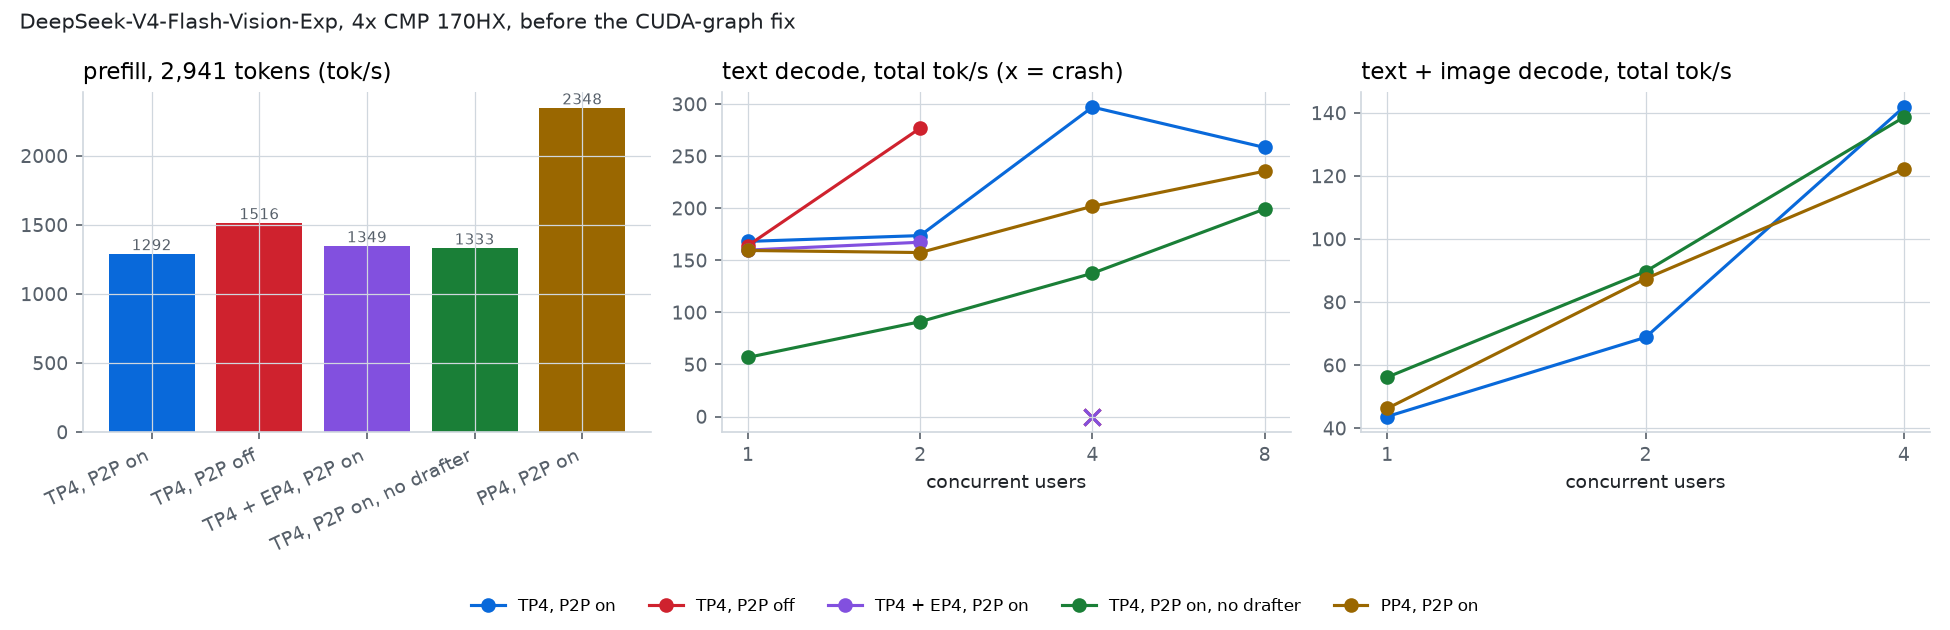

**Verdict (measured):** DeepSeek-V4-Flash-Vision now gives correct output on four CMP 170HX cards with tensor parallelism 4. A two-line fix in vLLM's CUDA-graph code removes off-topic replies to short prompts. An autoresearch loop (27 experiments in about 4 hours) found the fix. Speed is 80–130 tok/s for one user and 190–270 tok/s for four users. GLM-5.3-Flash on the same cards does 396–418 tok/s for one user.

```
docker pull ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba
```

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
AR = RESULTS_DIR + "/autoresearch"
LIVE = False  # True sends the final request to the endpoint in DSV4V_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "DSV4V_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/receipts


In [2]:
# --- Helpers ---
import json, csv, statistics
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def load(*parts):
    p = "/".join(parts)
    if not os.path.exists(p):
        return None
    with open(p) as f:
        return json.load(f)

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

def level(cfg, c, image=False):
    d = load(RECEIPTS, cfg, "ladder_image.json" if image else "ladder.json")
    for lv in (d or {}).get("levels", []):
        if lv.get("concurrency") == c:
            s = lv.get("summary") or {}
            return lv.get("status"), s.get("aggregate_tok_s_median")
    return None, None

def prefill(cfg):
    d = load(RECEIPTS, cfg, "prefill.json")
    v = [r["prefill_tok_s"] for r in (d or {}).get("reps", []) if r.get("prefill_tok_s")]
    return statistics.median(v) if v else None

def fmt(status, v):
    if status in (None,) and v is None:
        return "–"
    if status == "FAIL" or (v in (None, 0) and status):
        return "crash"
    return f"{v:.0f}" if v else "–"

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
S = ["#0969da", "#cf222e", "#8250df", "#1a7f37", "#9a6700"]
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})
CFGS = [("tp4-p2p", "TP4, P2P on"), ("tp4-nop2p", "TP4, P2P off"), ("tp4ep4-p2p", "TP4 + EP4, P2P on"),
        ("tp4-p2p-nodraft", "TP4, P2P on, no drafter"), ("pp4-p2p", "PP4, P2P on")]

## 1. TL;DR

- **Measured:** the 157 GB checkpoint runs on four 64 GiB cards with TP4 (40.8 GiB of weights per card, KV pool 142,953 tokens) and with PP4. TP4 starts in 7–11 minutes.
- **Measured:** before the fix, every layout gave off-topic replies to some short prompts. Two of four layouts with the drafter crashed at four users (illegal memory access), as did the 2026-09-02 PP4 run on another host.
- **Measured, root cause found:** a decorator checked the breakable-CUDA-graph switch at import time, before the DSpark config turned it on. DeepSeek-V4 attention was then captured inside CUDA graphs and replayed stale data for prompts that ran as a captured size (16 or 32 tokens). The fix decides at call time (section 3).
- **Measured:** an autoresearch loop in the style of [karpathy/autoresearch](https://github.com/karpathy/autoresearch) ran 27 experiments: 4 real wins, 12 discards, 5 crashes (section 4).
- **Measured:** P2P works on this driver (12 card pairs pass a byte-level content check). But NCCL is faster than vLLM's custom all-reduce over PCIe here (about 100 µs vs 186 µs per call), and `NCCL_P2P_LEVEL=SYS` costs about 15% of prefill (section 6).
- **Measured:** PP4 prefills 1.8× faster than TP4 (2,348 vs 1,292 tok/s). TP4 is faster for four users.
- **Inferred:** the gap to GLM-5.3-Flash (about 2–3×) is engine work: GLM has fused sm_80 decode kernels, and DeepSeek-V4 on this fork runs about 250 small kernels per decode step.

In [3]:
pins = {
    "served image (with the fixes)": "ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba",
    "base image (2026-09-02 vision image)": "ghcr.io/pixelml/club-170hx@sha256:b26232f8f041c988d3285e2278c9f5001cc49f96131bb0b22a9d38b5e5e061cd (allover326 SM80 fork f8ea5bb163c161ef38b401d055cc5fd4a934091a + 8-file SM80/DSpark patch set + vision port; see PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX)",
    "our changes": "results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/build (Dockerfile, 4 patched files, patches/fixes.patch, patches/custom_all_reduce.patch)",
    "model": "deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9 (48 shards, 167,819,404,368 bytes, checked file by file against the HF manifest)",
    "drafter": "DSpark from the checkpoint's MTP layers, num_speculative_tokens 6",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB unlock, BAR1 peer-to-peer)",
    "P2P check tool": "Morrowmake/glm53-flash-cmp170hx-recipe p2p_probe.cu @ e61ba680cd6f9497291cafa4ca13ac3ffbdab844 (v1.7.0)",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver (GPUs by CDI), 192 GiB memory limit",
    "topology": "4 cards behind two PLX switches, PCIe Gen2: three x16 and one x8 during these runs; 140 W power cap",
    "context": "16,384 tokens, fp8 KV, block size 256, 8 sequences, 2,048 batched tokens",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| served image (with the fixes) | ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba |
| base image (2026-09-02 vision image) | ghcr.io/pixelml/club-170hx@sha256:b26232f8f041c988d3285e2278c9f5001cc49f96131bb0b22a9d38b5e5e061cd (allover326 SM80 fork f8ea5bb163c161ef38b401d055cc5fd4a934091a + 8-file SM80/DSpark patch set + vision port; see PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX) |
| our changes | results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/build (Dockerfile, 4 patched files, patches/fixes.patch, patches/custom_all_reduce.patch) |
| model | deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9 (48 shards, 167,819,404,368 bytes, checked file by file against the HF manifest) |
| drafter | DSpark from the checkpoint's MTP layers, num_speculative_tokens 6 |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB unlock, BAR1 peer-to-peer) |
| P2P check tool | Morrowmake/glm53-flash-cmp170hx-recipe p2p_probe.cu @ e61ba680cd6f9497291cafa4ca13ac3ffbdab844 (v1.7.0) |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver (GPUs by CDI), 192 GiB memory limit |
| topology | 4 cards behind two PLX switches, PCIe Gen2: three x16 and one x8 during these runs; 140 W power cap |
| context | 16,384 tokens, fp8 KV, block size 256, 8 sequences, 2,048 batched tokens |

## 2. Five layouts before the fix (measured)

Same host, same 140 W cap, one server boot per row. Bench: `bench_harness.py` (prefill 2,941 tokens, unique prefix; ladder: 400 tokens, greedy, `ignore_eos`, 1 warm-up + 3 measured reps per level, median). Image ladder: one 64×64 PNG with each request. Quality: `correct.py` (5 known answers), `probe.py` (5 short prompts), `vision_check.py` (gradient: red, then green).

In [4]:
rows = []
for cfg, lab in CFGS:
    c = load(RECEIPTS, cfg, "correctness.json") or {}
    p = load(RECEIPTS, cfg, "probe.json") or []
    v = load(RECEIPTS, cfg, "vision-check.json") or {}
    pf = prefill(cfg)
    rows.append([lab, f"{pf:.0f}" if pf else "–"] + [fmt(*level(cfg, n)) for n in (1, 2, 4, 8)]
                + [fmt(*level(cfg, n, True)) for n in (1, 2, 4)]
                + [f"{c.get('correct', '–')}/{c.get('total', 5)}", f"{sum(x['on_topic'] for x in p)}/{len(p)}" if p else "–",
                   "pass" if v.get("keyword_match") else "–"])
table(["layout", "prefill", "c1", "c2 total", "c4 total", "c8 total", "image c1", "image c2", "image c4",
       "known answers", "probes on topic", "image answer"], rows)

| layout | prefill | c1 | c2 total | c4 total | c8 total | image c1 | image c2 | image c4 | known answers | probes on topic | image answer |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| TP4, P2P on | 1292 | 168 | 174 | 297 | 258 | 44 | 69 | 142 | 4/5 | 3/5 | pass |
| TP4, P2P off | 1516 | 164 | 277 | crash | – | crash | – | – | 4/5 | 3/5 | pass |
| TP4 + EP4, P2P on | 1349 | 160 | 167 | crash | – | crash | – | – | 4/5 | 3/5 | pass |
| TP4, P2P on, no drafter | 1333 | 57 | 91 | 138 | 199 | 56 | 90 | 139 | 4/5 | 2/5 | pass |
| PP4, P2P on | 2348 | 159 | 157 | 202 | 236 | 46 | 87 | 122 | 4/5 | 3/5 | pass |

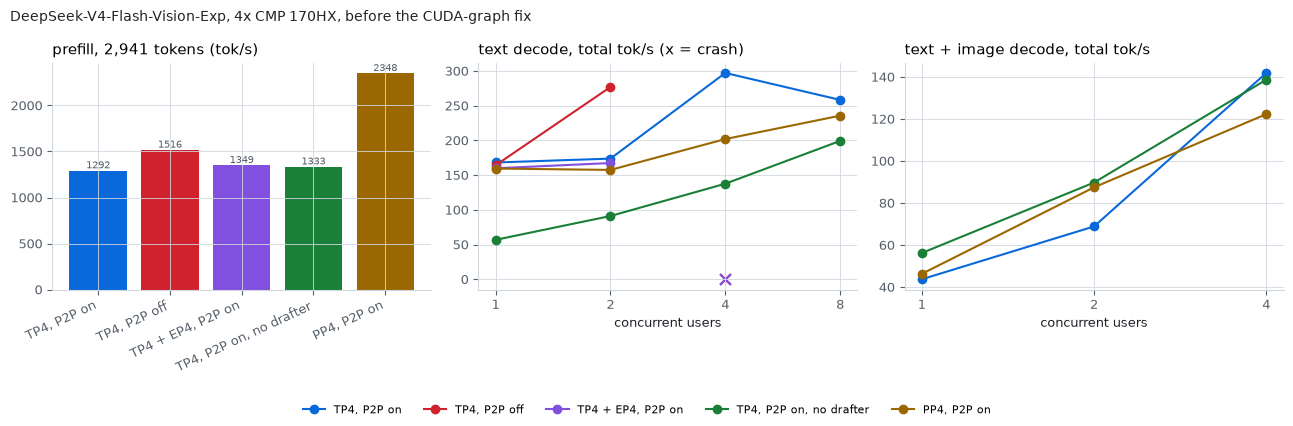

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
x = range(len(CFGS))
pf = [prefill(c) or 0 for c, _ in CFGS]
b = axes[0].bar(x, pf, color=[S[i % 5] for i in x]); axes[0].set_title("prefill, 2,941 tokens (tok/s)", loc="left")
for r, v in zip(b, pf): axes[0].text(r.get_x() + r.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
for i, (cfg, lab) in enumerate(CFGS):
    xs, ys = [], []
    for n in (1, 2, 4, 8):
        st, v = level(cfg, n)
        if v: xs.append(n); ys.append(v)
        elif st: axes[1].scatter([n], [0], marker="x", color=S[i % 5], s=60)
    axes[1].plot(xs, ys, marker="o", color=S[i % 5], label=lab)
axes[1].set_xscale("log", base=2); axes[1].set_xticks([1, 2, 4, 8], ["1", "2", "4", "8"])
axes[1].set_title("text decode, total tok/s (x = crash)", loc="left"); axes[1].set_xlabel("concurrent users")
for i, (cfg, lab) in enumerate(CFGS):
    xs, ys = [], []
    for n in (1, 2, 4):
        st, v = level(cfg, n, True)
        if v: xs.append(n); ys.append(v)
    axes[2].plot(xs, ys, marker="o", color=S[i % 5], label=lab)
axes[2].set_xscale("log", base=2); axes[2].set_xticks([1, 2, 4], ["1", "2", "4"])
axes[2].set_title("text + image decode, total tok/s", loc="left"); axes[2].set_xlabel("concurrent users")
axes[0].set_xticks(list(x), [l for _, l in CFGS], rotation=25, ha="right")
fig.legend(*axes[1].get_legend_handles_labels(), loc="lower center", ncol=5, fontsize=8, frameon=False)
fig.suptitle("DeepSeek-V4-Flash-Vision-Exp, 4x CMP 170HX, before the CUDA-graph fix", x=0.01, ha="left", fontsize=10, color=INK)
fig.tight_layout(rect=(0, 0.08, 1, 1))
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig(f"../assets/charts/{EXPERIMENT}.png", dpi=150); fig.savefig(f"../assets/charts/{EXPERIMENT}.svg")
plt.show()

- The drafter triples single-user decode (57 → 159–168 tok/s) but, before the fix, it crashed at four users in TP4 with P2P off and in TP4 + EP4.
- PP4 prefills 1.8× faster than TP4. TP4 needs two all-reduces in every layer for each prefill chunk; PP4 sends data only three times per chunk.
- Image requests decode at 40–56 tok/s for one user in every layout. The drafter accepts fewer tokens on image requests.

## 3. The off-topic bug and the fix (measured)

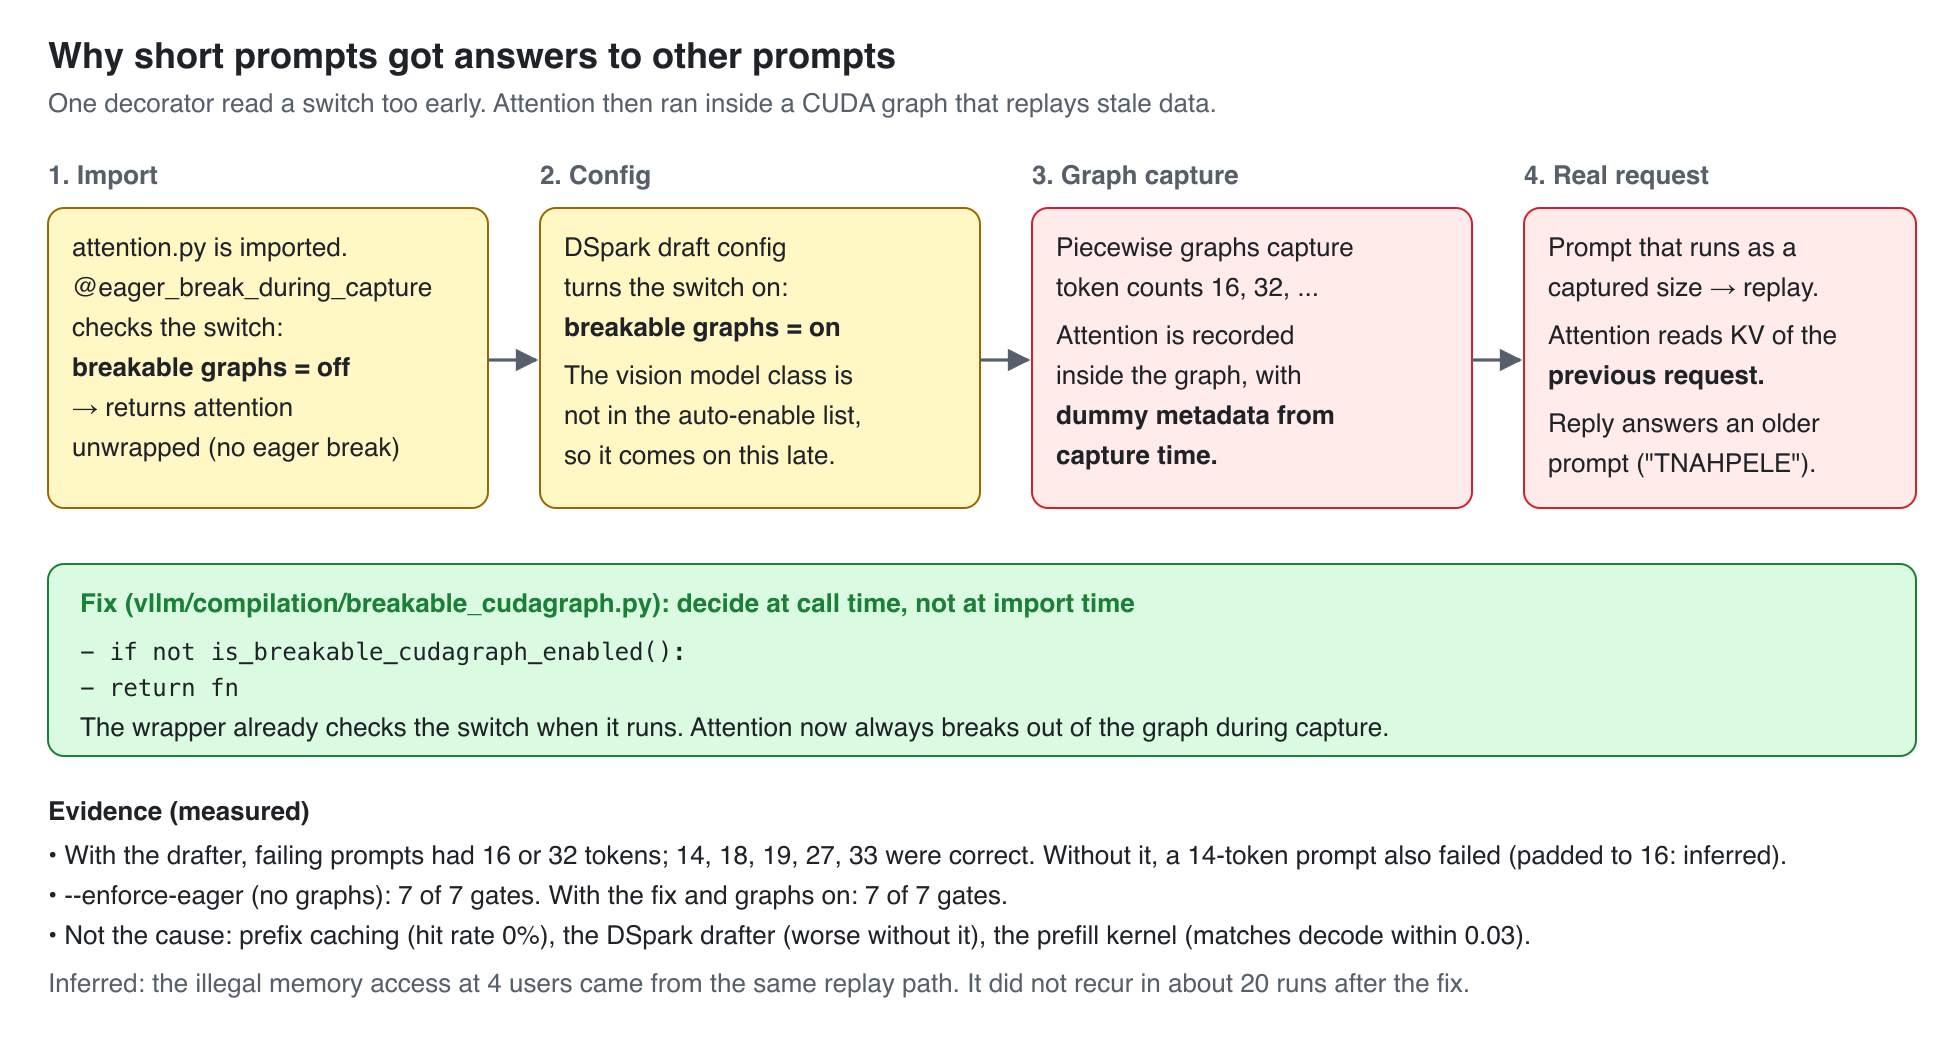

The patch is `build/patches/fixes.patch` (first hunk). The same decorator is in upstream vLLM, so other models that turn on breakable CUDA graphs late can have the same fault (inferred, not tested).

In [6]:
rows = []
for cfg, lab in CFGS:
    for p in load(RECEIPTS, cfg, "probe.json") or []:
        if not p["on_topic"]:
            rows.append([lab, p["name"], p["usage"]["prompt_tokens"], repr(p["content"][:70])])
table(["layout (before the fix)", "probe", "prompt tokens", "reply (first 70 characters)"], rows)

| layout (before the fix) | probe | prompt tokens | reply (first 70 characters) |
|---|---:|---:|---:|
| TP4, P2P on | prime-bare | 16 | '姉の友達が家に来た日、僕は自分の部屋にこもって本を読んでいた。しばらくして、トイレに行くために廊下に出ると、姉の友達がキッチンで何かを探して' |
| TP4, P2P on | prime-think | 16 | '姉妹の質問に答える。ユーザーは「姉妹の質問に答える」とだけ言っている。これは、以前の会話の文脈で姉妹から質問があったが、その内容がここに含ま' |
| TP4, P2P off | prime-bare | 16 | ' ' |
| TP4, P2P off | is_prime-97 | 32 | " True.  The function is `f(x) = x^3 - 3x + 1`.\n\nLet's find the critica" |
| TP4 + EP4, P2P on | prime-bare | 16 | '\nT-H-A-N-K-S' |
| TP4 + EP4, P2P on | is_prime-97 | 32 | ' True.  The `is` operator in Python checks for object identity, not va' |
| TP4, P2P on, no drafter | prime-bare | 16 | '' |
| TP4, P2P on, no drafter | prime-think | 16 | '4\n\nThe word "ELEPHANT" spelled backwards is "TNAHPELE". In uppercase, ' |
| TP4, P2P on, no drafter | sky | 14 | ' studio# 2019年5.2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. ' |
| PP4, P2P on | prime-bare | 16 | 'T' |
| PP4, P2P on | is_prime-97 | 32 | '' |

## 4. The autoresearch loop (measured)

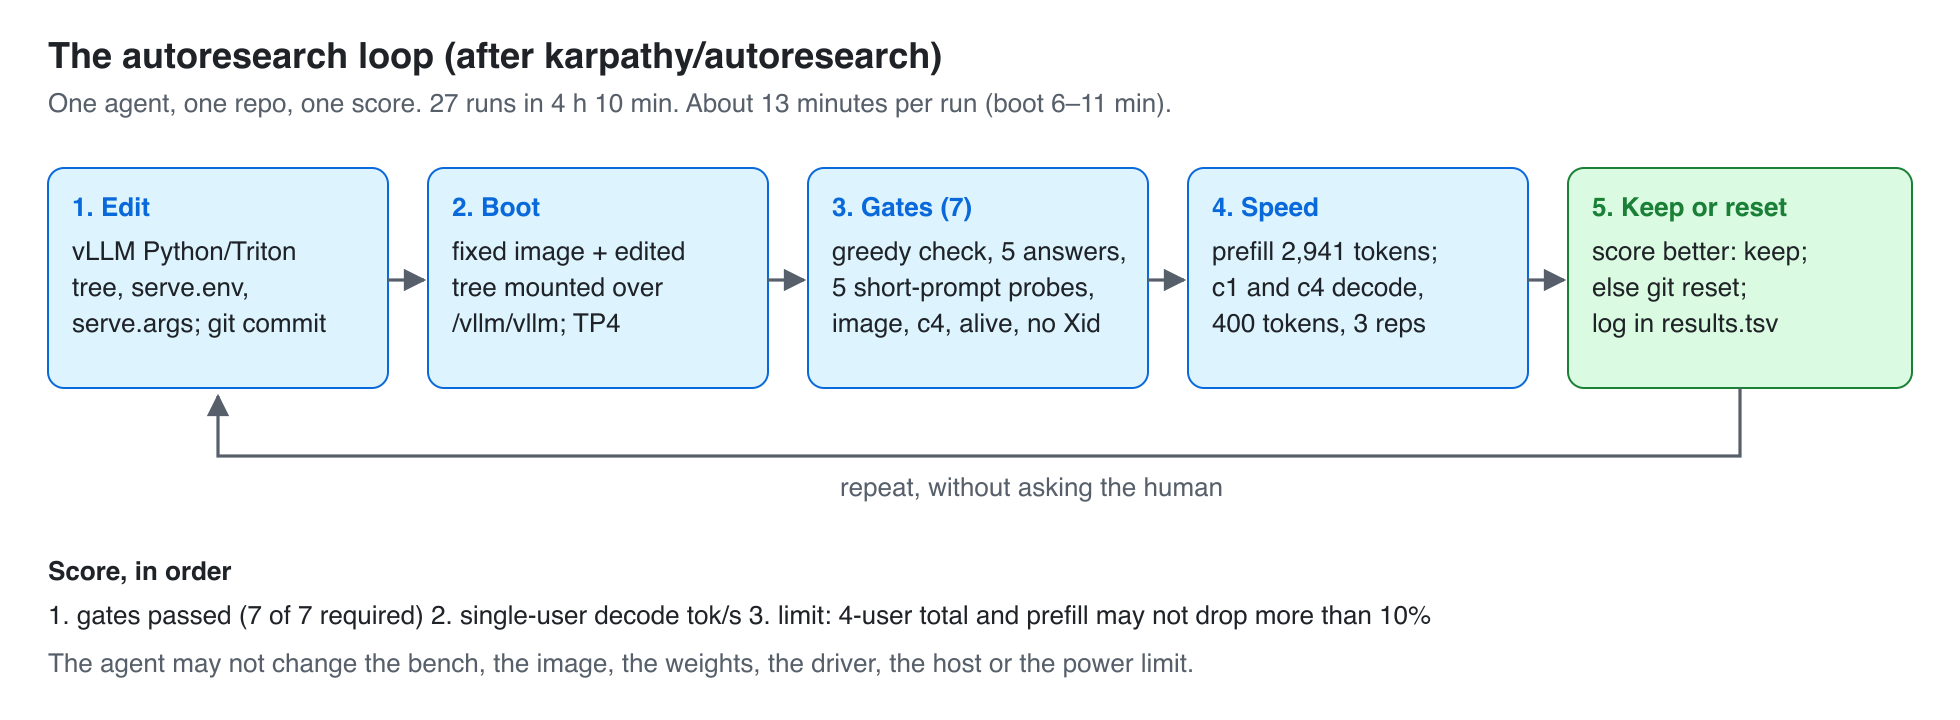

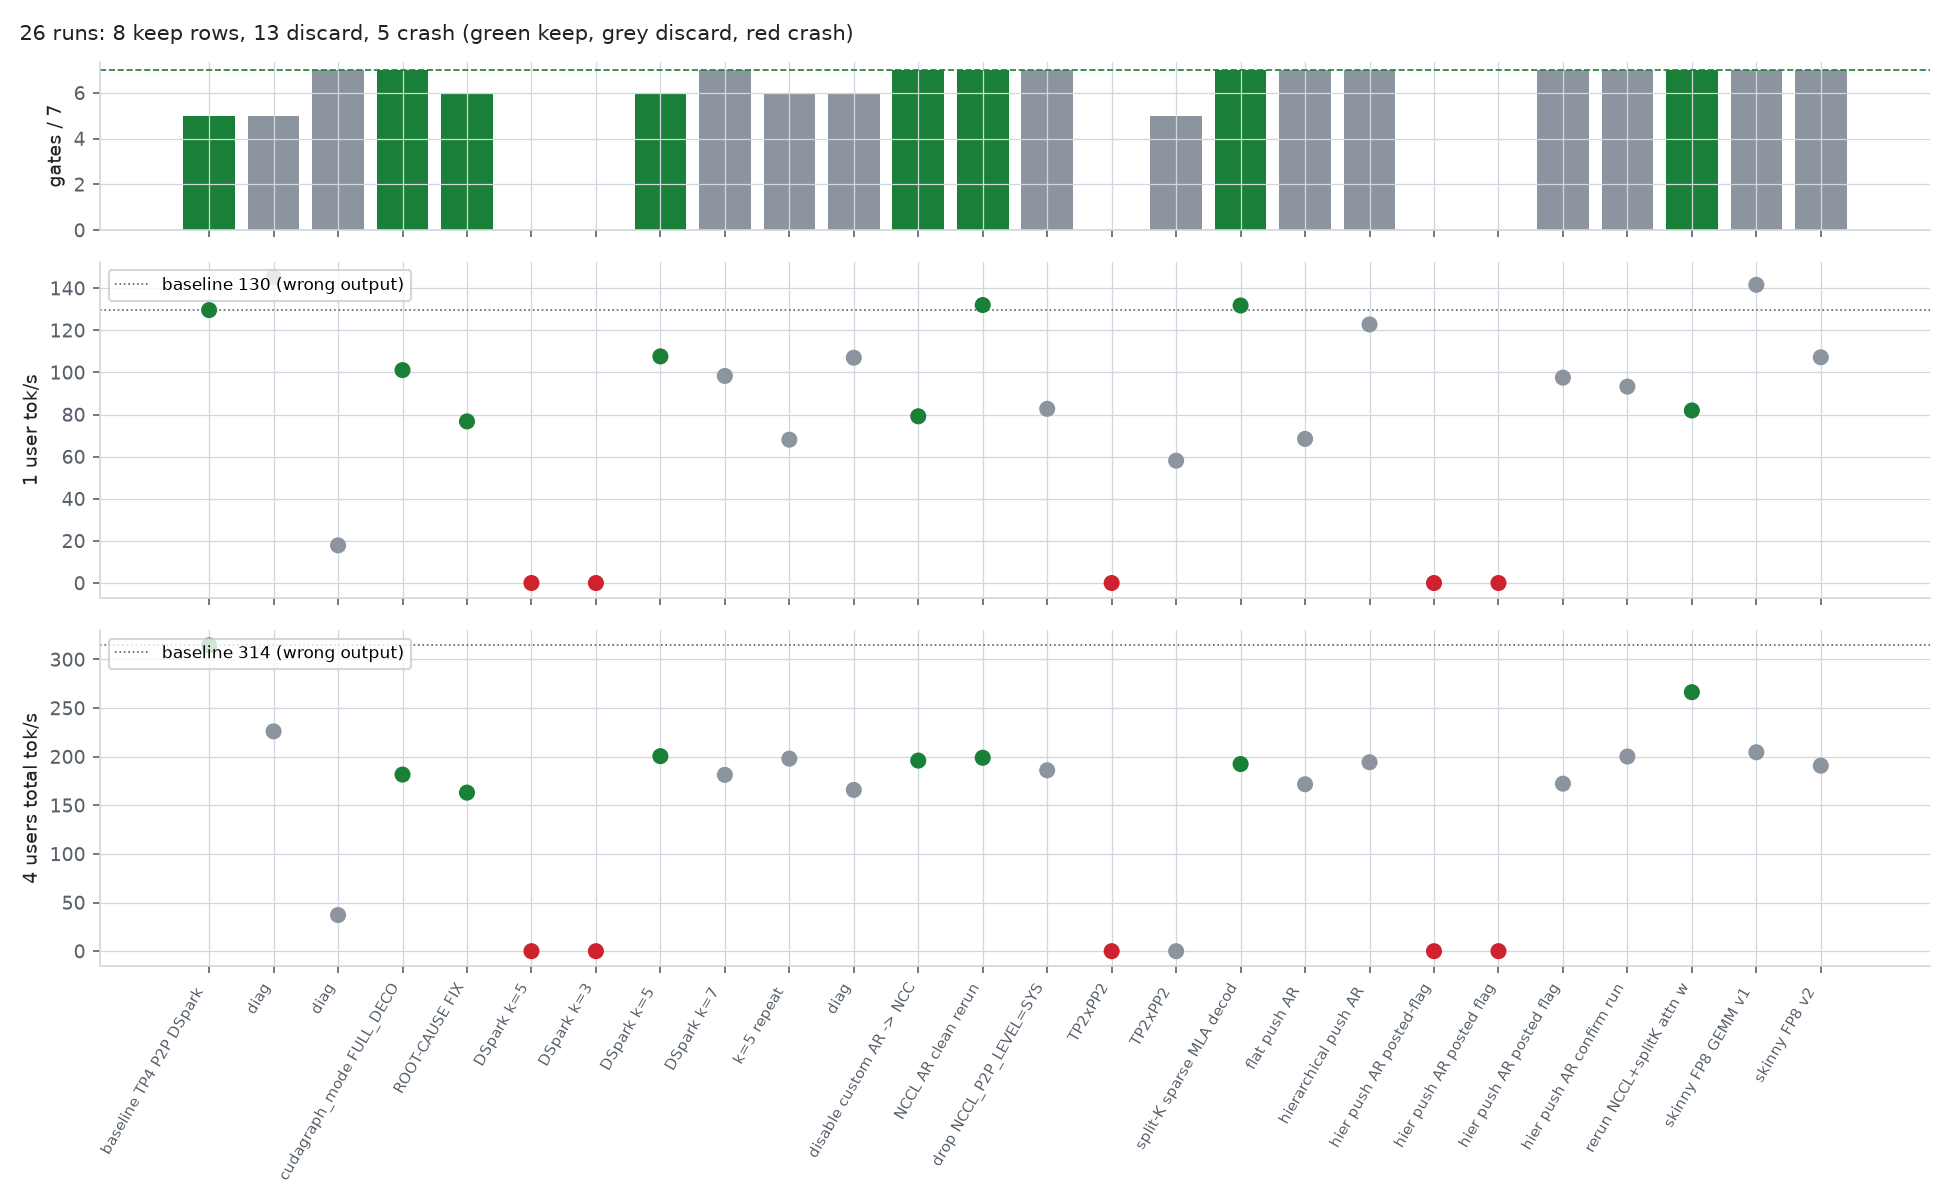

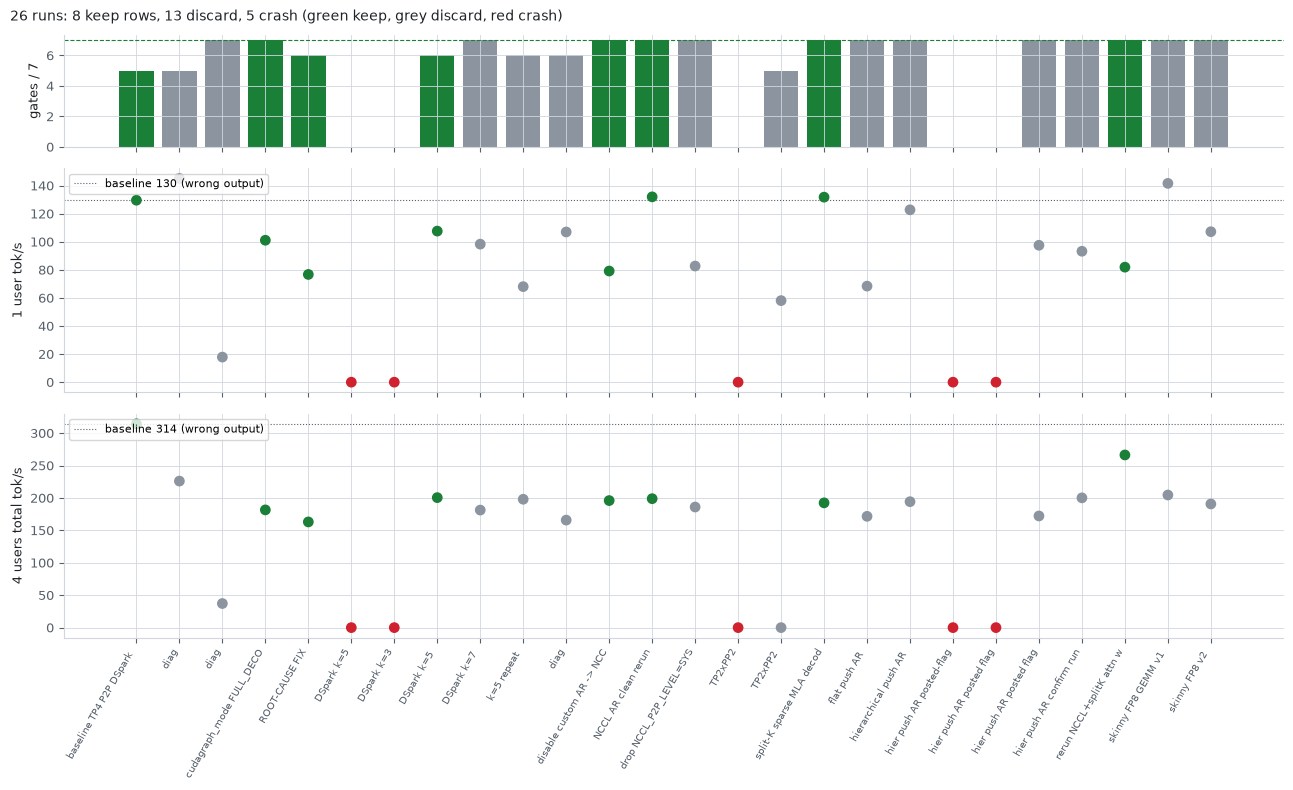

| commit | gates | c1 | c4 total | prefill | status | what |
|---|---:|---:|---:|---:|---:|---:|
| 8a1ea6a | 5/7 | 129.6 | 314.4 | 1288.2 | keep | baseline TP4 P2P DSpark k=6 (gates 2,3 fail) |
| ab61cfe | 5/7 | 145.17 | 226.04 | 1294.2 | discard | diag: --no-enable-prefix-caching + DSV4_DBG prefill-vs-decode attn compare (attn paths agr |
| 908bd17 | 7/7 | 17.87 | 37.15 | 1290.4 | discard | diag: --enforce-eager => 7/7 gates; bug is in CUDA-graph (breakable PIECEWISE) replay path |
| 63055f9 | 7/7 | 101.1 | 181.6 | 1340.7 | keep | cudagraph_mode FULL_DECODE_ONLY: first 7/7 (c1 runs 59/101/129, noisy) |
| eaf6b7f | 6/7* | 76.74 | 163.04 | 1291.5 | keep | ROOT-CAUSE FIX: eager_break_during_capture decided at import (env auto-enabled later) -> D |
| d221221 | 0/7 | 0 | 0 | 0 | crash | DSpark k=5: crash_boot (k must be divisible by n_predict=3) |
| 91d3461 | 0/7 | 0 | 0 | 0 | crash | DSpark k=3: crash_boot (DSpark requires k>=dspark_block_size=5) |
| 2dd3e01 | 6/7* | 107.61 | 200.54 | 1346.1 | keep? | DSpark k=5 (+skip n_predict divisibility for dspark); +6% c1 needs confirm; *gate7 spuriou |
| 6bb9c24 | 7/7 | 98.32 | 181.32 | 1333.1 | discard | DSpark k=7 (acceptance 3.2-3.8, no gain) |
| e18fa9a | 6/7* | 68.06 | 198.03 | 1343.2 | discard | k=5 repeat (profiler cfg idle): c1 61/68/128 -> k=5 mean c1 87.8, not better than k=6; c1  |
| 37ff927 | 6/7* | 106.99 | 165.85 | 1302.0 | discard | diag: torch profile of C1 warmup (k=6 FDO): custom AR 1stage 186us x94/step = 42% GPU time |
| 288b403 | 7/7 | 79.17 | 195.99 | 1308.6 | keep | disable custom AR -> NCCL RING_LL AR 99us vs custom 186us; c1 rep0 hit by profiler stall ( |
| 288b403 | 7/7 | 132.01 | 198.9 | 1296.5 | keep | NCCL AR clean rerun: c1 77/132/162 (+25% vs custom AR) |
| 3092c60 | 7/7 | 82.73 | 186.02 | 1489.6 | discard | drop NCCL_P2P_LEVEL=SYS: prefill +15% but c1 83/73/155 (noisy) c4 -6%; revisit |
| 5ab1c16 | 0/7 | 0 | 0 | 0 | crash | TP2xPP2: crash_boot, DSpark+PP embed load copies full vocab into TP shard |
| 12843c3 | 5/7 | 58.1 | 0 | 1993.9 | discard | TP2xPP2 (+DSpark PP embed TP-shard fix): prefill +54% but c1 58/99/58, c4 device-side asse |
| 89c7989 | 7/7 | 131.79 | 192.44 | 1283.1 | keep | split-K sparse MLA decode on sm8x: attn kernel 56->39.5us (profile), c1/c4 within noise |
| 0517ab1 | 7/7 | 68.43 | 171.67 | 1316.8 | discard | flat push AR (Triton, posted P2P writes): correct, but 145us/AR (PHB root complex forwards |
| cb4da07 | 7/7 | 122.78 | 194.28 | 1287.7 | discard | hierarchical push AR (remote atomic flags): 100us median/AR, no gain vs NCCL |
| d1a42cc | 0/7 | 0 | 0 | 0 | crash | hier push AR posted-flag variant: inline asm constraint bug (crash_boot) |
| f13fb85 | 0/7 | 0 | 0 | 0 | crash | hier push AR posted flags: bench 44us/57KB in graph; init bench used a size beyond slot -> |
| 0d572e5 | 7/7 | 97.52 | 172.25 | 1317.3 | discard | hier push AR posted flags: in-model AR 44us median (NCCL ~100-160); step period 27.9ms (wa |
| 0d572e5 | 7/7 | 93.25 | 200.17 | 1289.4 | discard | hier push AR confirm run: c1 88/93/96 (mean of 2 runs 95.4 < NCCL 132); step period 27.8ms |
| 89c7989 | 7/7 | 81.93 | 266.35 | 1321.0 | keep | rerun NCCL+splitK attn w/ profile: c1 82/81/155 (NCCL runs 132,132,82 -> c1 noise is run-t |
| b218593 | 7/7 | 141.6 | 204.56 | 1322.3 | discard | skinny FP8 GEMM v1 (bf16 bit-decode): correct (selfcheck err<=1e-3) but 150-290 GB/s, 8.5m |
| c2bb958 | 7/7 | 107.19 | 190.76 | 1323.3 | discard | skinny FP8 v2 (fp16 shift decode): 10-25us/call ~= Marlin 16-19us/call; step period 29.2ms |

In [7]:
rows = list(csv.DictReader(open(AR + "/results.tsv"), delimiter="\t"))
st = [r["status"].rstrip("?") for r in rows]
C = {"keep": "#1a7f37", "discard": "#8c959f", "crash": "#cf222e"}
fig, ax = plt.subplots(3, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [1, 2, 2]})
x = list(range(1, len(rows) + 1))
g = [int(r["gates"].split("/")[0]) for r in rows]
ax[0].bar(x, g, color=[C[s] for s in st]); ax[0].set_ylabel("gates / 7"); ax[0].axhline(7, color="#1a7f37", lw=0.8, ls="--")
for i, (k, lab) in enumerate([("c1_tok_s", "1 user tok/s"), ("c4_agg_tok_s", "4 users total tok/s")], 1):
    v = [float(r[k]) for r in rows]
    ax[i].scatter(x, v, c=[C[s] for s in st], s=45, zorder=3); ax[i].set_ylabel(lab)
    ax[i].axhline(v[0], color=INK2, lw=0.8, ls=":", label=f"baseline {v[0]:.0f} (wrong output)"); ax[i].legend(loc="upper left", fontsize=8)
ax[2].set_xticks(x, [r["description"].split(":")[0].split("(")[0][:24] for r in rows], rotation=60, ha="right", fontsize=7)
n_keep, n_disc, n_crash = st.count("keep"), st.count("discard"), st.count("crash")
fig.suptitle(f"{len(rows)} runs: {n_keep} keep rows, {n_disc} discard, {n_crash} crash (green keep, grey discard, red crash)", x=0.01, ha="left", fontsize=10, color=INK)
fig.tight_layout(); fig.savefig(f"../assets/charts/{EXPERIMENT}-autoresearch.png", dpi=150); plt.show()
table(["commit", "gates", "c1", "c4 total", "prefill", "status", "what"],
      [[r["commit"], r["gates"], r["c1_tok_s"], r["c4_agg_tok_s"], r["prefill_tok_s"], r["status"], r["description"][:90]] for r in rows])

The 8 keep rows contain the baseline, two confirmation reruns and DSpark k=5 (a later rerun rejected it). That leaves 4 real wins:

| Win | Effect (measured) |
|---|---|
| `cudagraph_mode FULL_DECODE_ONLY` | first run with 7 / 7 gates |
| Decorator fix in `breakable_cudagraph.py` | removes the stale replay in any graph mode |
| `--disable-custom-all-reduce` (NCCL for all-reduce) | about 100 µs instead of 186 µs per call; c1 132 in two clean runs |
| Split-K sparse-MLA decode on sm_80 | attention decode kernel 56 → 39.5 µs |

**Noise (measured):** greedy output is not identical from run to run on this engine, so draft acceptance changes. The same commit gave 132 and 82 tok/s for one user. Treat a single c1 number as ±40%.

**Why four-user throughput fell from 314 (measured):** the baseline's wrong output was repetitive, and the drafter predicted it easily (4.68 accepted tokens per step against about 3.5 now). Mixed prefill + decode steps run without a CUDA graph in `FULL_DECODE_ONLY` mode (inferred cost, not measured).

## 5. Where a decode step goes (measured with the torch profiler)

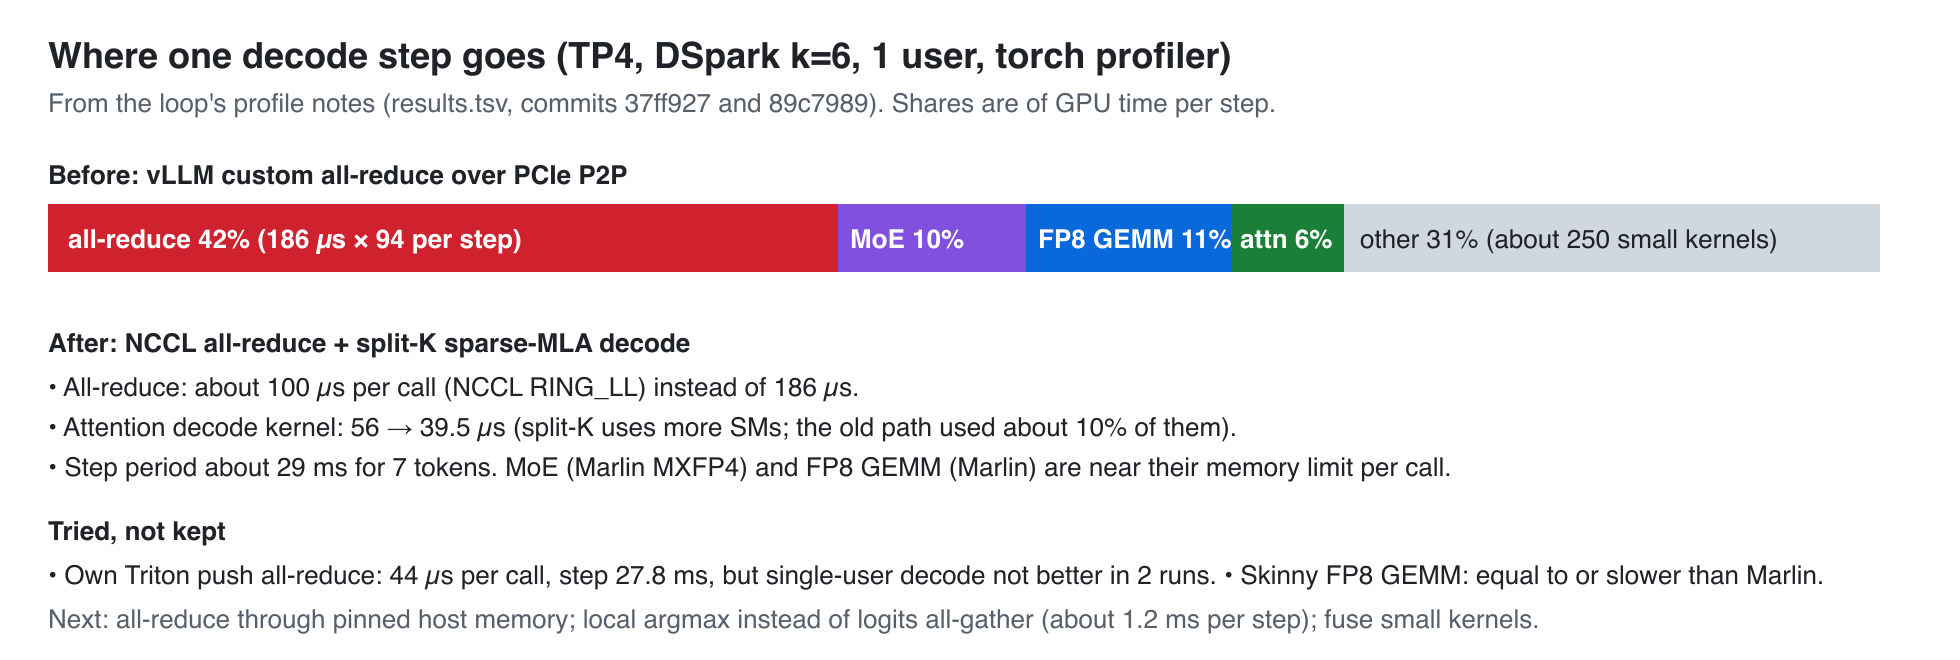

## 6. P2P (measured)

- **Content check:** Morrowmake's `p2p_probe.cu` (v1.7.0) passes on this driver: 12 ordered card pairs, 9 sizes from 128 KiB to 32 MiB, memcpy, SM writes and reads, and CUDA IPC writes, all byte-identical (`receipts/p2p-content-check.json`).
- **Custom all-reduce:** with `VLLM_FORCE_CUSTOM_AR_PCIE=1`, vLLM's one-stage custom kernel takes 186 µs per call and 42% of the decode step. NCCL (`RING_LL`) takes about 100 µs. The served config uses NCCL.
- **`NCCL_P2P_LEVEL=SYS`:** prefill is 15% slower with it (1,290 vs 1,490 tok/s in the loop; 1,292 vs 1,529 in the layout runs). Decode did not change within the noise. It stays in the served config because the 7 / 7 runs used it; removing it is the next easy test.
- **Own Triton push all-reduce:** 44 µs per call and a 27.8 ms step (NCCL: 29.0 ms), but single-user decode was not better in two runs.

In [8]:
def telemetry(cfg):
    p = f"{RECEIPTS}/{cfg}/telemetry.csv"
    if not os.path.exists(p): return None
    t, w = [], []
    for r in list(csv.reader(open(p), skipinitialspace=True))[1:]:
        try: t.append(float(r[2])); w.append(float(r[3].split()[0]))
        except (ValueError, IndexError): pass
    return t, w
rows = []
for cfg, lab in CFGS:
    tw = telemetry(cfg)
    if tw and tw[0]:
        rows.append([lab, f"{max(tw[0]):.0f}", f"{statistics.mean(tw[1]):.0f}", f"{max(tw[1]):.0f}"])
table(["layout", "peak core °C", "mean W per card", "peak sampled W (cap 140 W)"], rows)

| layout | peak core °C | mean W per card | peak sampled W (cap 140 W) |
|---|---:|---:|---:|
| TP4, P2P on | 72 | 98 | 152 |
| TP4, P2P off | 67 | 89 | 139 |
| TP4 + EP4, P2P on | 68 | 88 | 143 |
| TP4, P2P on, no drafter | 72 | 97 | 143 |
| PP4, P2P on | 72 | 97 | 197 |

## 7. Reproduce

Hardware: 4 × CMP 170HX with 65,536 MiB each (64 GiB unlock), working BAR1 peer-to-peer, forced-air cooling, about 180 GB of disk for the weights.

```bash
# 1. Weights
hf download deepseek-ai/DeepSeek-V4-Flash-Vision-Exp --revision 86f746b36186f0e567729a5c06a8c918caba82a9 --local-dir /path/to/DeepSeek-V4-Flash-Vision-Exp

# 2. Serve: TP4, DSpark k=6, NCCL all-reduce, full CUDA graphs for decode only (the served config)
docker run -d --name dsv4v --gpus all --ipc=host --ulimit memlock=-1 --shm-size 16g -p 8000:8000 \
  -e HF_HUB_OFFLINE=1 -e VLLM_WORKER_MULTIPROC_METHOD=spawn -e VLLM_ENGINE_READY_TIMEOUT_S=3600 \
  -e NCCL_P2P_LEVEL=SYS -e PYTORCH_CUDA_ALLOC_CONF=expandable_segments:False \
  -v /path/to/DeepSeek-V4-Flash-Vision-Exp:/model:ro \
  ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba \
  vllm serve /model --served-model-name dsv4v --tensor-parallel-size 4 --kv-cache-dtype fp8 --block-size 256 \
  --max-model-len 16384 --max-num-batched-tokens 2048 --trust-remote-code --gpu-memory-utilization 0.90 \
  --max-num-seqs 8 --disable-custom-all-reduce --compilation-config '{"cudagraph_mode":"FULL_DECODE_ONLY"}' \
  --no-enable-flashinfer-autotune --tokenizer-mode deepseek_v4 \
  --speculative-config '{"method":"dspark","num_speculative_tokens":6}' \
  --hf-overrides '{"architectures":["DeepseekV4ForConditionalGeneration"]}' --limit-mm-per-prompt '{"image":2}'

# 3. Power cap used here
nvidia-smi -pl 140
```

The loop's runs also had `VLLM_FORCE_CUSTOM_AR_PCIE=1 VLLM_CUSTOM_AR_MAX_BYTES=131072` (inactive with `--disable-custom-all-reduce`) and an idle `--profiler-config` (acts only on `/start_profile`); both are left out above. The layout runs in section 2 used the base image with `build/run.sh` (`LAYOUT`, `P2P`, `EP`, `DRAFT` switches) and `build/protocol.sh`. The loop's harness, rules and log are in `autoresearch/` (`run_experiment.sh`, `program.md`, `results.tsv`, `NOTES.md`). PP4 needs `--pipeline-parallel-size 4` and `VLLM_PP_LAYER_PARTITION=11,11,11,10`.

## Try your own prompt

Edit `PROMPT`. With `LIVE = False`, the cell prints a recorded probe reply from the first gate run after the fix.

In [9]:
PROMPT = "Name the two colors this gradient blends between, left color first."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "dsv4v", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 400, "temperature": 0}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    print(resp["choices"][0]["message"]["content"]); print(resp["usage"])
else:
    import glob
    runs = sorted(glob.glob(AR + "/runs/*-89c7989"))
    v = load(runs[0], "vision.json") if runs else None
    print(v["question"], "->", v["answer"]) if v else print("no recorded run")

Name the two colors this gradient blends between, left color first. -> Based on the image provided, the gradient blends between the following two colors, left color first:

1.  **Red** (on the left)
2.  **Green** (on the right)


<details><summary>Appendix: notes</summary>

- The 2026-09-02 vision notebook measured PP4 on another host at 180 W: 119 tok/s median single-user, 2,352 tok/s prefill, crash at four users. This page is the TP4 follow-up on the 4-card PLX host.
- One card ran at PCIe Gen2 x8 during these runs. The other three ran at x16.
- Gate 7 (no new Xid) failed spuriously in four loop runs: the kernel log rotated out old lines, so the count dropped. No new Xid came from those runs.
- The loop agent ran one CPU-only `docker run --rm` of the base image to read its Triton version (3.7.1). Its rules said not to start other containers.
- Licences: vLLM is Apache-2.0; the model is MIT (per its model card).
</details>